In [ ]:
pip install ultralytics

## Session 1

1. import Yolo

In [1]:
import ultralytics
from ultralytics import YOLO
import cv2
from IPython.display import Image, display

ultralytics.checks()
model = YOLO("yolo26n.pt")
print("Model is ready.")

Ultralytics 8.4.128 🚀 Python-3.14.6 torch-2.13.0 CPU (Apple M5 Pro)
Setup complete ✅ (18 CPUs, 64.0 GB RAM, 238.3/926.3 GB disk)
Model is ready.


In [ ]:
# list the model items
print(len(model.names))
print(model.names)

### Beyond class names: the model's own parameters

`model.names` only lists the 80 category labels YOLO can recognize — that describes what the model was trained to detect, not the model itself. To help students understand the model as a piece of engineering — how deep it is, how many trainable weights ("parameters") it holds, and how much computation it takes to run — use `model.info()`. This prints a summary line: number of layers, number of parameters, number of gradients (trainable parameters during training), and GFLOPs (a measure of computational cost per image — higher means more work for the processor per prediction).

In [ ]:
# summary: layers, parameters, gradients, GFLOPs(Giga Floating-Point Operations)
model.info()
layers, parameters, gradients, flops = model.info()
print(f"This model has {parameters} parameters")


**Going deeper — every layer, one by one**

`model.info(detailed=True)` breaks that summary line down into every individual layer inside the network, in order: its index, name, whether it's trainable, how many parameters it holds, its shape, and its module type (e.g. a convolution layer, a batch-norm layer). This is a good way for students to see that "the model" isn't one single thing — it's a long stack of smaller layers, each contributing a share of the total parameter count shown above.

In [ ]:
# every layer of the network, one by one
model.info(detailed=True)

**A different kind of "parameter" — settings you can tune**

So far, "parameters" meant the trained weights inside the network — numbers the model learned and that students can't hand-edit. There's a second, everyday meaning worth distinguishing for students: the configurable settings that control how the model runs, like `conf` (minimum confidence to keep a detection) or `iou` (how much overlap counts as a duplicate box) seen in earlier cells. `DEFAULT_CFG` from `ultralytics` lists every one of these settings and its default value, whether or not you've overridden it yet.

2. items identify

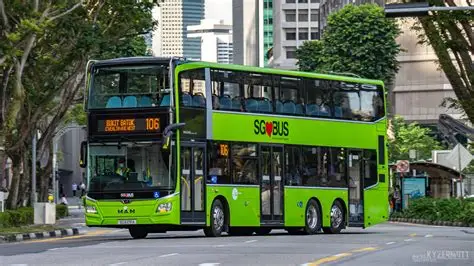

In [3]:
Image("bus.webp")

In [ ]:
# find things in one picture
picture = cv2.imread("bus.webp")
results = model(picture)

print(results)

In [ ]:
# find things in one picture
picture = cv2.imread("bus.webp")
results = model(picture)
print(model.predictor.args)

In [ ]:
# find things in one picture
picture = cv2.imread("bus.webp")
results = model(picture)

print(model.predictor.args)

for box in results[0].boxes:
    class_id = int(box.cls[0])
    name = model.names[class_id]

print(name)

In [5]:
# find things in one picture
picture = cv2.imread("bus.webp")
results = model(picture, verbose=False)

for box in results[0].boxes:
    class_id = int(box.cls[0])
    name = model.names[class_id]
    
print(f"The model recognized: {name}")

The model recognized: bus


### Showing the confidence score

Besides `box.cls` (which class) and `box.xyxy` (where), each `box` also carries `box.conf` — how sure the model is about that detection, as a value between 0 and 1 (closer to 1 means more confident). Like `box.cls`, it comes back as a one-element tensor, so it needs `float(box.conf[0])` to pull out a plain Python number.

In [9]:
# find things in one picture, with confidence
picture = cv2.imread("busy high way.webp")
results = model(picture, verbose=False)

for box in results[0].boxes:
    class_id = int(box.cls[0])
    name = model.names[class_id]
    conf = float(box.conf[0])
    print(f"The model recognized : {name} with the confidence of:{conf:.2f}")

The model recognized : bus with the confidence of:0.82
The model recognized : car with the confidence of:0.82
The model recognized : car with the confidence of:0.59
The model recognized : car with the confidence of:0.59
The model recognized : car with the confidence of:0.50
The model recognized : car with the confidence of:0.47
The model recognized : car with the confidence of:0.43
The model recognized : car with the confidence of:0.42
The model recognized : car with the confidence of:0.41
The model recognized : car with the confidence of:0.38
The model recognized : car with the confidence of:0.37
The model recognized : car with the confidence of:0.36
The model recognized : truck with the confidence of:0.34


In [ ]:
# map(function_name, list_name)
scores = ["10", "8", "9", "7"]

int_scores = []
for score in scores:
    int_scores.append(int(score))

print(int_scores)


In [ ]:
scores = ["10", "8", "9", "7"]

int_scores = [int(score) for score in scores]
print(int_scores)


In [ ]:
scores = ["10", "8", "9", "7"]

int_scores = map(int, scores)
print(list(int_scores))


### Center point and box size

`box.xyxy` gives the two opposite corners of a detection, which is precise but not the most convenient form for steering a robot toward an object. `box.xywh` gives the same box in a different shape: `[center_x, center_y, width, height]`. The center point is exactly what a robot's turning logic needs — for example, "if `center_x` is left of the frame's middle, turn left; if right, turn right" — and `width × height` is a quick stand-in for how close the object is, since a nearer object fills more of the frame.

Like `box.cls` and `box.conf`, `box.xywh` comes back as a small tensor (one row: `[[cx, cy, w, h]]`), so `box.xywh[0]` unwraps that single row before converting each value to a plain number.

In [3]:
# find things in one picture, with center point and size
picture = cv2.imread("bus.webp")
results = model(picture, verbose=False)

for box in results[0].boxes:
    class_id = int(box.cls[0])
    name = model.names[class_id]
    cx, cy, w, h = map(int, box.xywh[0])

print(f"{name}: center=({cx}, {cy}), size={w}x{h}")

bus: center=(235, 147), size=310x180


bus


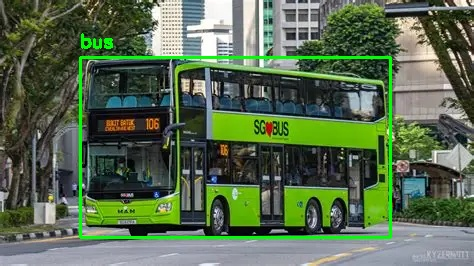

In [10]:
# find things in one picture, with a box drawn around each
picture = cv2.imread("bus.webp")
results = model(picture, verbose=False)

for box in results[0].boxes:
    class_id = int(box.cls[0])
    name = model.names[class_id]

    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cv2.rectangle(picture, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(picture, name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

print(name)

cv2.imwrite("bus_boxed.jpg", picture)
display(Image("bus_boxed.jpg"))

bus
car
car
car
car
car
car
car
car
car
car
car
truck


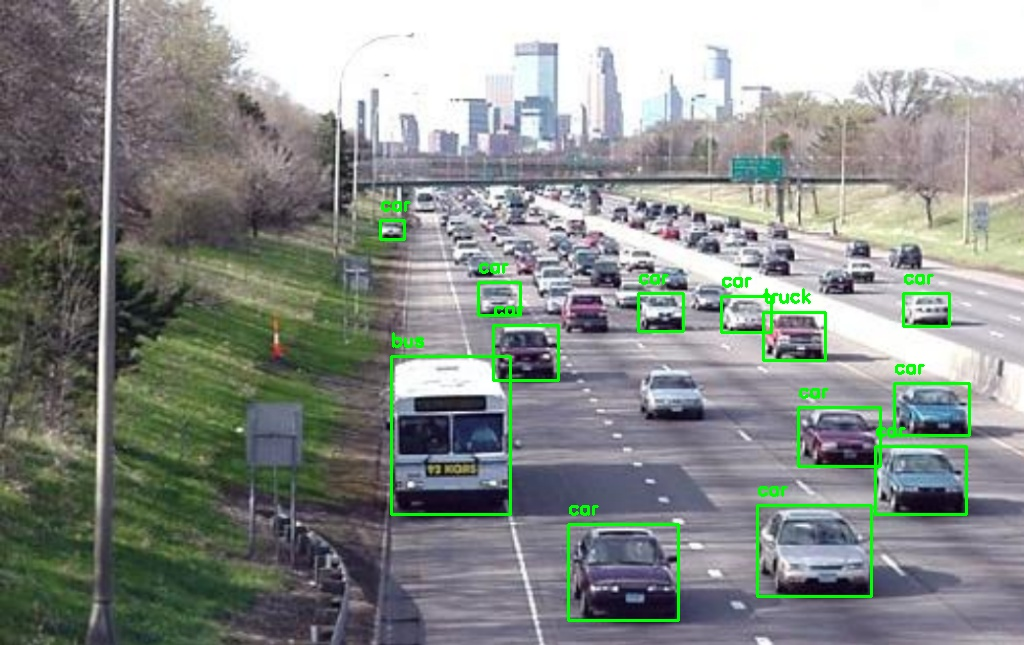

In [14]:
# find things in one picture, with a box drawn around each
picture = cv2.imread("busy high way.webp")
results = model(picture, verbose=False)

for box in results[0].boxes:
    class_id = int(box.cls[0])
    name = model.names[class_id]

    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cv2.rectangle(picture, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(picture, name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    print(name)

cv2.imwrite("busy high way_boxed.jpg", picture)
display(Image("busy high way_boxed.jpg"))

In [20]:
# find things in one picture
picture = cv2.imread("busy high way.webp")
results = model(picture, verbose=False)

for box in results[0].boxes:
    class_id = int(box.cls[0])
    name = model.names[class_id]
    print(name)

bus
car
car
car
car
car
car
car
car
car
car
car
truck


In [19]:
# counter items in one picture
from collections import Counter

picture = cv2.imread("busy high way.webp")
results = model(picture, verbose=False)

names = []
for box in results[0].boxes:
    class_id = int(box.cls[0])
    name = model.names[class_id]
    names.append(name)

counts =Counter(names)
print(counts)

Counter({'car': 11, 'bus': 1, 'truck': 1})


### Counting detections with `Counter`

The loop above prints one class name per detected object, but it doesn't tally them. To get totals like "12 cars, 1 bus, 1 truck," collect the names into a list first, then hand that list to `Counter` from Python's built-in `collections` module. `Counter` takes any list and returns a dictionary-like object mapping each unique item to how many times it appeared — exactly what's needed here.

In [13]:
from collections import Counter

picture = cv2.imread("busy high way.webp")
results = model(picture, verbose=False)

names = [model.names[int(box.cls[0])] for box in results[0].boxes]
counts = Counter(names)

for name, count in counts.items():
    print(name, count)

bus 1
car 11
truck 1


### Drawing the bounding boxes onto the image

Every `Result` object (like `results[0]`) has a `.plot()` method that returns a copy of the original image with all the bounding boxes, labels, and confidence scores already drawn onto it. It comes back as a NumPy array in BGR color order (OpenCV's default channel order), so it needs converting to RGB before displaying with matplotlib — otherwise the colors look swapped (blue and red reversed).

Note: the later cells in this notebook (`681b1568`, `c87b422a`) try `Image.fromarray(...)`, expecting PIL's `Image` class — but the import at the top of the notebook, `from IPython.display import Image, display`, replaced that name with a different `Image` class that has no `fromarray` method. That's the cause of the `AttributeError` shown in those cells' output. Using matplotlib below sidesteps that naming clash entirely.

In [ ]:
import matplotlib.pyplot as plt

picture = cv2.imread("busy high way.webp")
results = model(picture, verbose=False)

annotated = results[0].plot()          # BGR numpy array with boxes drawn
annotated_rgb = annotated[..., ::-1]   # convert BGR -> RGB for correct colors

plt.imshow(annotated_rgb)
plt.axis("off")
plt.show()

In [ ]:
# find things in two pictures
picture = [cv2.imread("busy high way.webp"),cv2.imread("shopping mall.jpeg")]
results = model(picture, verbose=False)

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        name = model.names[class_id]
        print(name)

3. classroom items identify

In [ ]:
picture = cv2.imread("zoo.jpg")
results = model(picture, verbose=False)

for box in results[0].boxes:
    print(model.names[int(box.cls[0])])

## Session 2

1. print the confidence

In [ ]:
picture = cv2.imread("shopping mall.jpeg")
results = model(picture, verbose=False)

for box in results[0].boxes:
    name = model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    print(name, conf)

2. only show the ones with strong confidence

In [ ]:
picture = cv2.imread("shopping mall.jpeg")
results = model(picture, verbose=False)

for box in results[0].boxes:
    name = model.names[int(box.cls[0])]
    conf = float(box.conf[0])

    if conf > 0.9:
        print(name, conf)

## Session 3

1. print the corners

In [ ]:
picture = cv2.imread("shopping mall.jpeg")
results = model(picture, verbose=False)

box = results[0].boxes[0]

x1 = int(box.xyxy[0][0])
y1 = int(box.xyxy[0][1])
x2 = int(box.xyxy[0][2])
y2 = int(box.xyxy[0][3])

print(x1, y1, x2, y2)